In [1]:
import pandas as pd
import numpy as np
import datetime as dt

import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("data.csv")

power = list(df['power'])

In [3]:
forecast = []

for i in range(71424, len(power)):
    forecast.append(np.mean(power[i - 96*5 : i : 96]))

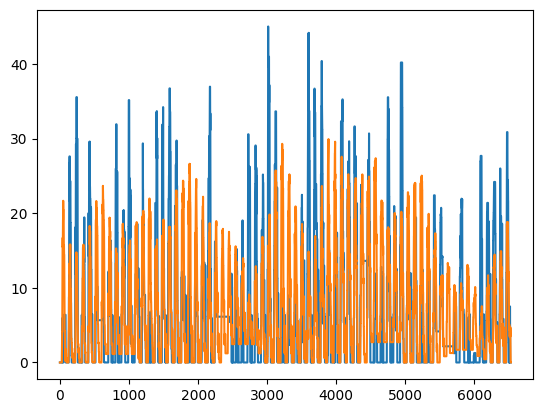

In [4]:
test = power[71424:]

plt.plot(test)
plt.plot(forecast)

In [5]:
from sklearn.metrics import root_mean_squared_error

rmse = root_mean_squared_error(test, forecast)
rmse

7.712673727456558

In [6]:
alpha = 2


weights = np.array([alpha if num == 1 else 1 for num in np.sign(np.array(test) - np.array(forecast))])
wrmse = np.sqrt(np.mean(weights**2 * (np.array(test) - np.array(forecast))**2))

print(f"RMSE={rmse}\tWRMSE={wrmse}")

RMSE=7.712673727456558	WRMSE=12.617472291030696


In [7]:
1 - sum(np.array(test) - np.array(forecast)) / len(test)

0.8288585511680822